# DeBERTa-v3 Model-Size Scaling on SuperTweetEval

**Research question :** Does increasing language model size improve performance across different social media NLP tasks?

**Setup:**
- Model: DeBERTa-v3 — **XSmall / Base / Large**
- Tasks: **TweetEmotion** (11-class multi-label), **TweetTopic** (19-class multi-label), **TweetSim** (0–5 regression)
- Training: 3 epochs, learning rate 2×10⁻⁵, batch size 16, max sequence length 128, seed 42, FP16
- Evaluation: Macro-F1 (classification tasks), Spearman correlation (similarity)
- Data: `cardiffnlp/super_tweeteval` on the Hugging Face Hub


## 1. Setup

In [2]:
!pip install -q transformers datasets accelerate scikit-learn scipy sentencepiece evaluate pandas matplotlib

In [3]:
!rm -f results.csv

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr
from sklearn.metrics import f1_score
from datasets import load_dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected — go to Runtime > Change runtime type > T4 GPU, then re-run.")


## 2. Task & data configuration

In [ ]:
TASK_CONFIG = {
    "tweet_emotion": {
        "type": "multi_label",
        "num_labels": 11,
        "text_fields": ("text",),
        "label_field": "gold_label_list",
    },
    "tweet_topic": {
        "type": "multi_label",
        "num_labels": 19,
        "text_fields": ("text",),
        "label_field": "gold_label_list",
    },
    "tweet_similarity": {
        "type": "regression",
        "num_labels": 1,
        "text_fields": ("text_1", "text_2"),
        "label_field": "gold_score",
    },
}

MODEL_CHECKPOINTS = {
    "xsmall": "microsoft/deberta-v3-xsmall",
    "base": "microsoft/deberta-v3-base",
    "large": "microsoft/deberta-v3-large",
}

MODEL_PARAMS_M = {"xsmall": 22, "base": 86, "large": 304}

def load_task(task_name):
    return load_dataset("cardiffnlp/super_tweeteval", task_name)


## 3. Tokenization

In [ ]:
def build_tokenize_fn(tokenizer, task_name, max_length=128):
    cfg = TASK_CONFIG[task_name]
    text_fields = cfg["text_fields"]
    label_field = cfg["label_field"]

    def tokenize_fn(batch):
        if len(text_fields) == 1:
            enc = tokenizer(batch[text_fields[0]], truncation=True, max_length=max_length)
        else:
            enc = tokenizer(batch[text_fields[0]], batch[text_fields[1]], truncation=True, max_length=max_length)

        labels = batch[label_field]
        if cfg["type"] == "regression":
            enc["labels"] = [[float(v)] for v in labels]
        else:
            enc["labels"] = [[float(x) for x in row] for row in labels]
        return enc

    return tokenize_fn


## 4. Metrics — Macro-F1 and Spearman correlation

Macro-F1 for the two multi-label tasks, a correlation-based metric (Spearman r) for similarity.

In [ ]:
def multi_label_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    labels = labels.astype(int)
    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    return {"macro_f1": round(macro_f1 * 100, 2)}

def regression_metrics(eval_pred):
    preds, labels = eval_pred
    preds = np.asarray(preds).reshape(-1)
    labels = np.asarray(labels).reshape(-1)
    corr, _ = spearmanr(preds, labels)
    if np.isnan(corr):
        corr = 0.0
    return {
        "spearman_r": round(corr * 100, 2),
        "spearman_r_floored": round(max(corr, 0.0) * 100, 2),
    }

METRIC_FN = {"multi_label": multi_label_metrics, "regression": regression_metrics}


## 5. Training function

Hyperparameters — 3 epochs, lr 2e-5, batch size 16, max length 128, seed 42, FP16.



In [ ]:
EPOCHS = 3
LEARNING_RATE = 2e-5
BATCH_SIZE = 16
MAX_LENGTH = 128
SEED = 42
USE_FP16 = True

import re

def make_training_args(output_dir):
    # Builds TrainingArguments defensively — transformers versions differ on
    # which kwargs are supported (e.g. eval_strategy vs evaluation_strategy),
    # so unsupported ones are dropped and the call retried.
    desired = dict(
        output_dir=output_dir,
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE * 2,
        learning_rate=LEARNING_RATE,
        weight_decay=0.01,
        warmup_ratio=0.06,
        logging_steps=25,
        fp16=USE_FP16 and torch.cuda.is_available(),
        seed=SEED,
        report_to=[],
        save_strategy="no",
    )

    dropped = []
    args = None
    while args is None:
        try:
            args = TrainingArguments(**desired)
        except TypeError as e:
            m = re.search(r"unexpected keyword argument '([^']+)'", str(e))
            if not m or m.group(1) not in desired:
                raise
            bad_key = m.group(1)
            dropped.append(bad_key)
            del desired[bad_key]

    if dropped:
        print(f"note: this transformers version doesn't accept {dropped} — continuing without them.")
    return args


def run_experiment(task_name, model_size, max_length=MAX_LENGTH):
    set_seed(SEED)
    task_cfg = TASK_CONFIG[task_name]
    checkpoint = MODEL_CHECKPOINTS[model_size]
    run_name = f"{task_name}_{model_size}"
    output_dir = f"runs/{run_name}"

    print(f"\n=== {run_name}  ({checkpoint}) ===")

    raw = load_task(task_name)
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    tokenize_fn = build_tokenize_fn(tokenizer, task_name, max_length=max_length)
    tokenized = raw.map(tokenize_fn, batched=True, remove_columns=raw["train"].column_names)

    problem_type = "multi_label_classification" if task_cfg["type"] == "multi_label" else "regression"
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint, num_labels=task_cfg["num_labels"], problem_type=problem_type
    )
    model = model.float()
    args = make_training_args(output_dir)

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=METRIC_FN[task_cfg["type"]],
    )

    trainer.train()

    val_metrics = trainer.evaluate(tokenized["validation"], metric_key_prefix="val")
    print("validation:", val_metrics)
    test_metrics = trainer.evaluate(tokenized["test"], metric_key_prefix="test")
    print("test:", test_metrics)

    row = {
        "task": task_name,
        "model_size": model_size,
        "params_millions": MODEL_PARAMS_M[model_size],
    }
    row.update({k.replace("test_", ""): v for k, v in test_metrics.items()})

    del model, trainer
    torch.cuda.empty_cache()
    return row


## 6. Run the full grid (XSmall / Base / Large × 3 tasks = 9 runs)

Every finished run is appended to `results.csv` immediately

In [ ]:
TASKS = ["tweet_similarity", "tweet_topic", "tweet_emotion"]  # smallest/fastest dataset first
SIZES = ["xsmall", "base", "large"]

RESULTS_CSV = "results.csv"

ALL_COLUMNS = ["task", "model_size", "params_millions", "loss",
               "macro_f1", "spearman_r", "spearman_r_floored"]

def already_done(task, size):
    if not os.path.exists(RESULTS_CSV):
        return False
    df = pd.read_csv(RESULTS_CSV)
    return ((df["task"] == task) & (df["model_size"] == size)).any()

n_saved = 0
n_failed = 0

for task in TASKS:
    for size in SIZES:
        if already_done(task, size):
            print(f"skipping {task}/{size} — already in {RESULTS_CSV}")
            continue
        try:
            row = run_experiment(task, size)
        except Exception:
            import traceback
            print(f"\n!! run FAILED for {task}/{size} — full error below:")
            traceback.print_exc()
            n_failed += 1
            continue

        write_header = not os.path.exists(RESULTS_CSV)
        row_df = pd.DataFrame([row]).reindex(columns=ALL_COLUMNS)
        row_df.to_csv(RESULTS_CSV, mode="a", header=write_header, index=False)
        print("saved:", row)
        n_saved += 1

print(f"\n=== grid summary: {n_saved} runs saved this pass, {n_failed} failed ===")
if not os.path.exists(RESULTS_CSV):
    print("results.csv was NOT created — every run above failed.")



=== tweet_similarity_xsmall  (microsoft/deberta-v3-xsmall) ===


README.md:   0%|          | 0.00/30.2k [00:00<?, ?B/s]

data/tweet_similarity/train.jsonl: reconstructing file:   0%|          |  0.00B /  121kB            

data/tweet_similarity/train.jsonl: downloading bytes:           |  0.00B            

data/tweet_similarity/test.jsonl: reconstructing file:   0%|          |  0.00B /  118kB            

...

Step,Training Loss
25,0.557491
50,0.472387
75,0.426278
100,0.401460
125,0.390827
150,0.362884
175,0.386062
200,0.349207
225,0.340005
250,0.352243


Training Loss,Validation Loss,Step,Macro F1
0.209968,0.275837,1284,56.970000


validation: {'val_loss': 0.275836706161499, 'val_macro_f1': 56.97}


Training Loss,Validation Loss,Step,Macro F1
0.209968,0.273715,1284,55.130000


test: {'test_loss': 0.27371546626091003, 'test_macro_f1': 55.13}
saved: {'task': 'tweet_emotion', 'model_size': 'large', 'params_millions': 304, 'loss': 0.27371546626091003, 'macro_f1': 55.13}

=== grid summary: 9 runs saved this pass, 0 failed ===


## 7. Look at your results table

In [ ]:
assert os.path.exists(RESULTS_CSV)

results = pd.read_csv(RESULTS_CSV)
print(f"{len(results)} run(s) recorded so far (9 total expected: 3 sizes x 3 tasks).")
missing = [(t, s) for t in ["tweet_emotion", "tweet_topic", "tweet_similarity"] for s in ["xsmall", "base", "large"]
           if not ((results["task"] == t) & (results["model_size"] == s)).any()]
if missing:
    print("Still missing:", missing, "— re-run Section 6 to fill these in (it skips what's already done).")

macro_col = results["macro_f1"] if "macro_f1" in results.columns else pd.Series(np.nan, index=results.index)
spearman_col = results["spearman_r_floored"] if "spearman_r_floored" in results.columns else pd.Series(np.nan, index=results.index)
results["score"] = macro_col.combine_first(spearman_col)
display(results[["task", "model_size", "params_millions", "score"]].sort_values(["task", "params_millions"]))

pivot = results.pivot_table(index="model_size", columns="task", values="score")
pivot = pivot.reindex(["xsmall", "base", "large"])
display(pivot)


9 run(s) recorded so far (9 total expected: 3 sizes x 3 tasks).


,task,model_size,params_millions,score
6,tweet_emotion,xsmall,22,31.36
7,tweet_emotion,base,86,49.83
8,tweet_emotion,large,304,55.13
0,tweet_similarity,xsmall,22,8.97
1,tweet_similarity,base,86,60.74
2,tweet_similarity,large,304,68.90
3,tweet_topic,xsmall,22,11.30
4,tweet_topic,base,86,22.41
5,tweet_topic,large,304,40.66


task,tweet_emotion,tweet_similarity,tweet_topic
model_size,,,
xsmall,31.36,8.97,11.30
base,49.83,60.74,22.41
large,55.13,68.90,40.66


## 8. Build the three poster figures

One figure per task — Emotion, Topic, Similarity.

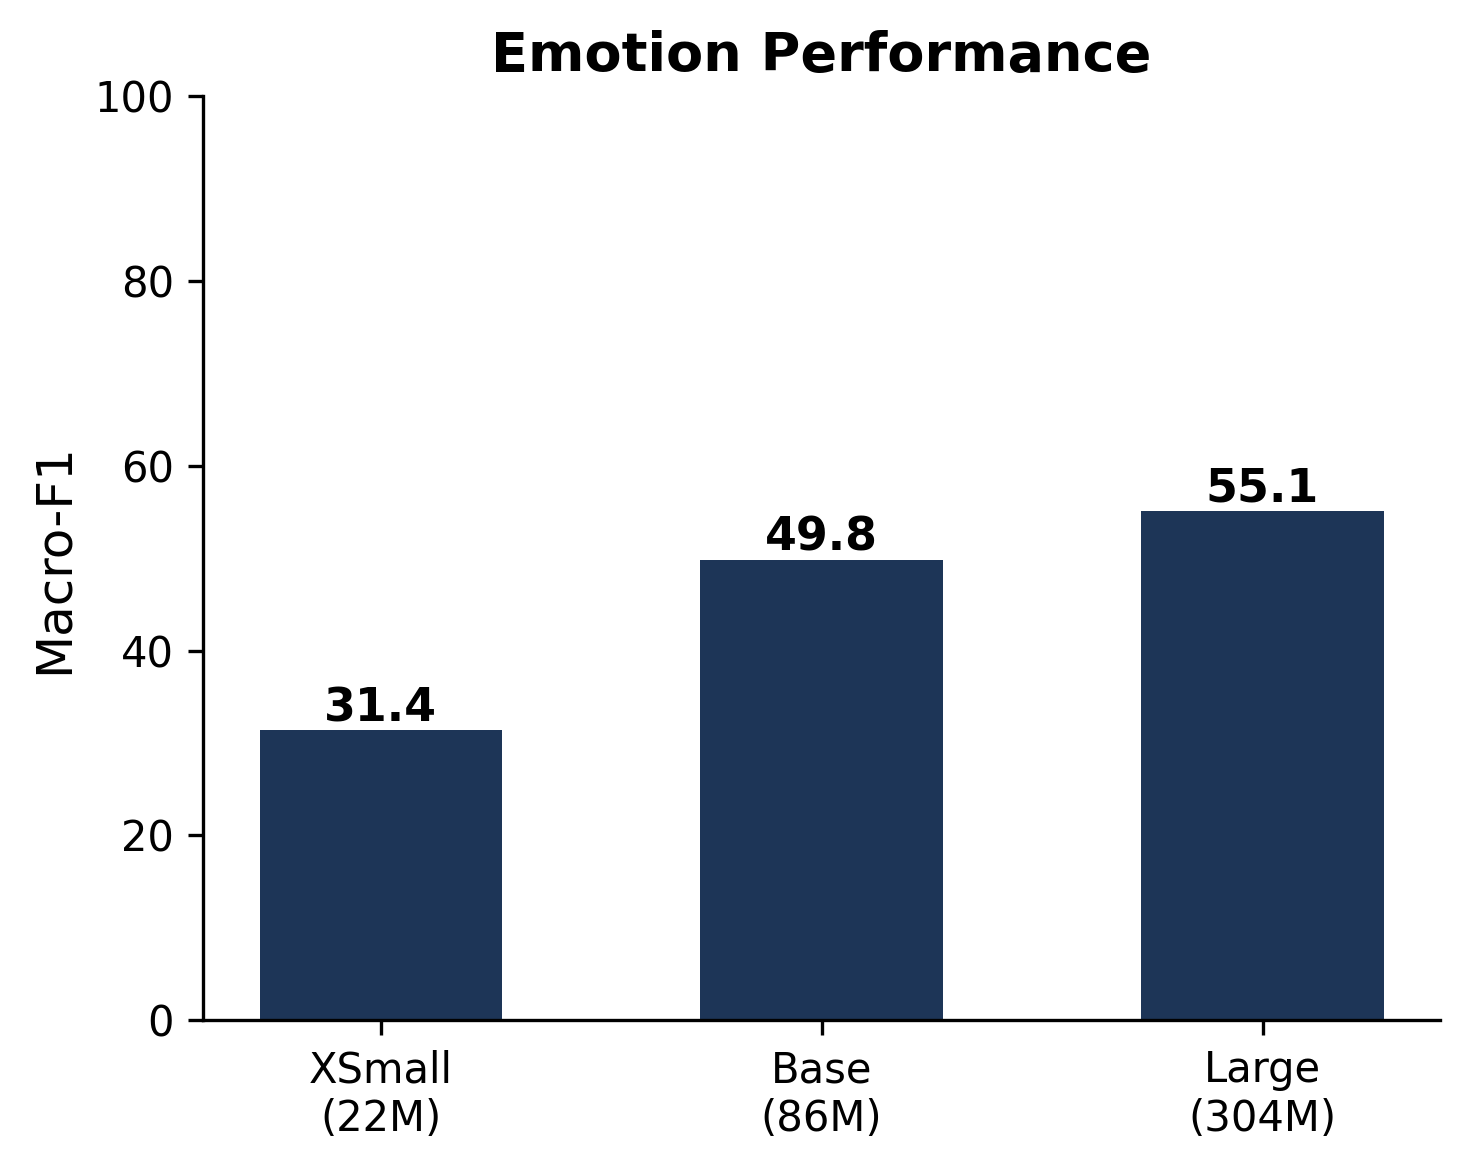

saved emotion_performance.png


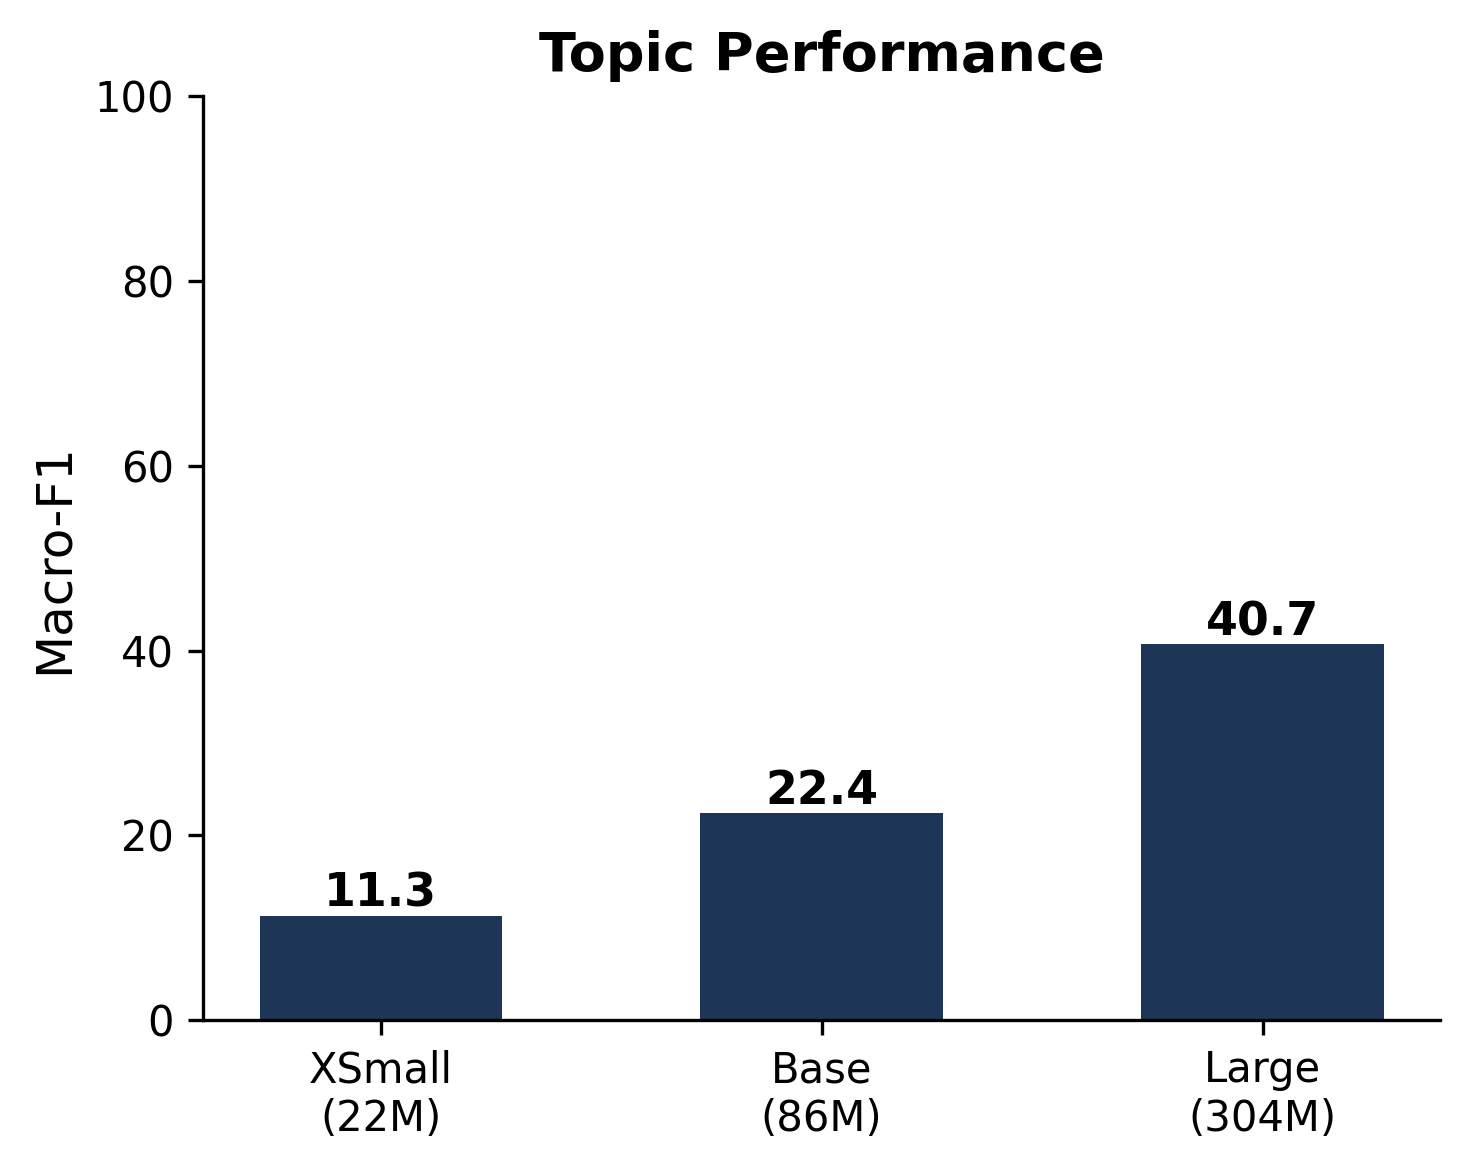

saved topic_performance.png


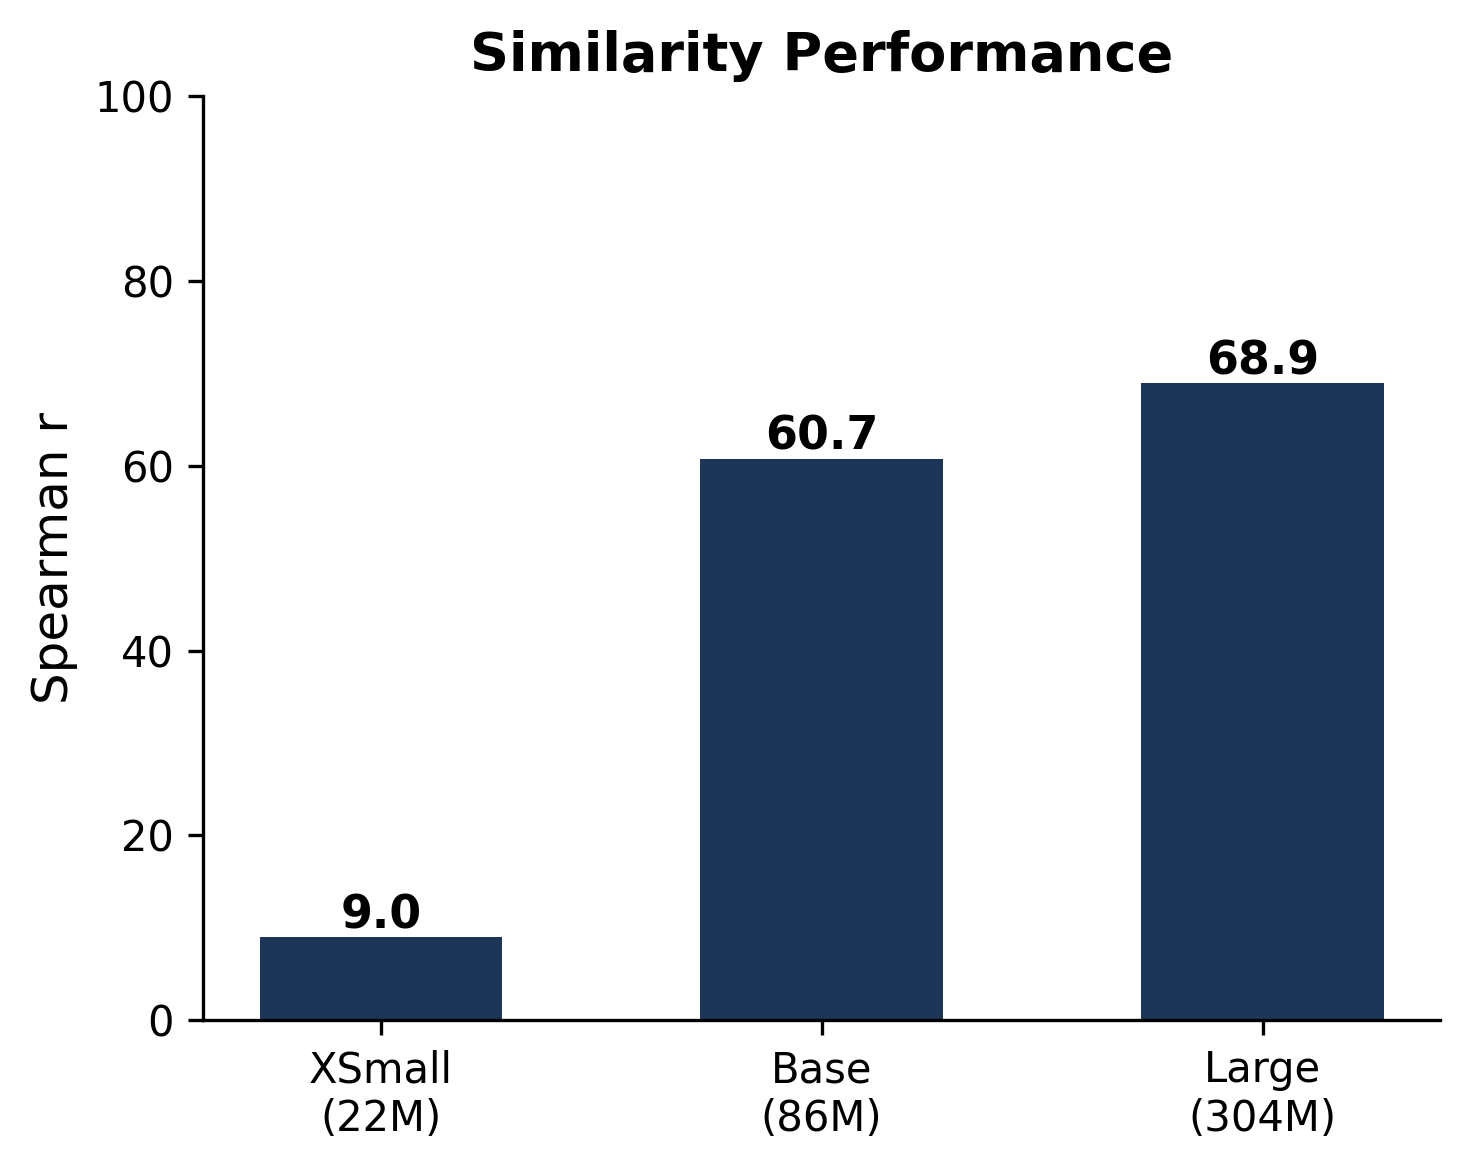

saved similarity_performance.png


In [ ]:
import matplotlib.pyplot as plt

TASK_TITLES = {
    "tweet_emotion": ("Emotion Performance", "Macro-F1"),
    "tweet_topic": ("Topic Performance", "Macro-F1"),
    "tweet_similarity": ("Similarity Performance", "Spearman r"),
}
SIZE_ORDER = ["xsmall", "base", "large"]
SIZE_LABELS = {"xsmall": "XSmall\n(22M)", "base": "Base\n(86M)", "large": "Large\n(304M)"}
BAR_COLOR = "#1d3557"

def plot_task(task_name, out_path):
    title, ylabel = TASK_TITLES[task_name]
    sub = results[results["task"] == task_name].set_index("model_size").reindex(SIZE_ORDER)

    fig, ax = plt.subplots(figsize=(5, 4), dpi=300)
    bars = ax.bar([SIZE_LABELS[s] for s in SIZE_ORDER], sub["score"], color=BAR_COLOR, width=0.55)
    for bar, val in zip(bars, sub["score"]):
        if pd.notna(val):
            ax.text(bar.get_x() + bar.get_width() / 2, val + 1, f"{val:.1f}", ha="center", fontsize=11, fontweight="bold")

    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_ylim(0, 100)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.show()
    print(f"saved {out_path}")

plot_task("tweet_emotion", "emotion_performance.png")
plot_task("tweet_topic", "topic_performance.png")
plot_task("tweet_similarity", "similarity_performance.png")


## 9. Overall Comparison


In [ ]:
def trend_word(sub):
    vals = sub.reindex(SIZE_ORDER)["score"].values
    if pd.isna(vals).any():
        return "incomplete"
    if vals[0] < vals[1] < vals[2]:
        return "a consistent increase"
    if vals[0] > vals[1] > vals[2]:
        return "a consistent decrease"
    return "an inconsistent / non-monotonic pattern"

lines = []
for task in ["tweet_emotion", "tweet_topic", "tweet_similarity"]:
    sub = results[results["task"] == task]
    t = trend_word(sub)
    title = TASK_TITLES[task][0].replace(" Performance", "")
    lines.append(f"- {title}: {t} as model size increases (XSmall -> Base -> Large).")

## 10. Download everything to your computer

In [ ]:
import shutil
shutil.make_archive("deberta_results", "zip", ".", "results.csv")

from google.colab import files
files.download("results.csv")
files.download("emotion_performance.png")
files.download("topic_performance.png")
files.download("similarity_performance.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>